# Publication-Quality Bayesian Optimization for Cu₃VS₄ Nanoparticle Synthesis

This notebook implements a **theoretically rigorous** constrained Bayesian optimization framework.

**IMPORTANT: Run cells in order (1 → 2 → 3 → ...)**

In [1]:
# =============================================================================
# CELL 1: IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import norm, spearmanr
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False
})

COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'tertiary': '#F18F01',
    'success': '#2E8B57', 'warning': '#E63946'
}

print("✓ Imports successful!")

✓ Imports successful!


In [2]:
# =============================================================================
# CELL 2: CONFIGURATION - EDIT THIS
# =============================================================================
DATA_PATH = r"/Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Data/COMPLETE_CUVS_DATA_PDI.csv"

FACTOR_ORDER = ["Temp", "Time", "VOacac", "DDT", "OAm"]
OBJECTIVES = ["Size", "PDI", "Squareness"]
FEAS_COLS = ["HasProduct", "PhasePure"]
POLYMORPH_COL = "Polymorph"
CUBIC_LABEL = "cubic"

BOUNDS = {
    "Temp":   (260.0, 310.0),
    "Time":   (8.0, 90.0),
    "VOacac": (0.08, 0.66),
    "DDT":    (1.0, 5.0),
    "OAm":    (1.0, 7.0),
}

OBJECTIVE_WEIGHTS = {"PDI": 1.5, "Squareness": 0.5}

print("✓ Configuration set!")

✓ Configuration set!


In [3]:
# =============================================================================
# CELL 3: DATA LOADING
# =============================================================================
@dataclass
class Constraint:
    min_val: float
    max_val: float

def load_and_prepare_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path) if path.endswith('.csv') else pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    
    for c in FACTOR_ORDER + OBJECTIVES:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    for c in FEAS_COLS:
        df[c] = df[c].astype(bool).astype(int)
    
    if POLYMORPH_COL in df.columns:
        df["IsCubic"] = (df[POLYMORPH_COL].astype(str).str.lower().str.strip() == CUBIC_LABEL.lower()).astype(int)
    else:
        df["IsCubic"] = 1
    
    return df.dropna(subset=FACTOR_ORDER).reset_index(drop=True)

df = load_and_prepare_data(DATA_PATH)
bounds = {k: Constraint(v[0], v[1]) for k, v in BOUNDS.items()}

print(f"✓ Loaded {len(df)} experiments ({df['HasProduct'].sum()} successful)")
display(df.head())

✓ Loaded 40 experiments (30 successful)


,Temp,Time,VOacac,DDT,OAm,Run_ID,PDI,Squareness,Size,PhasePure,HasProduct,Polymorph,IsCubic
0,260,8,0.08,1.0,7.0,1,NaN,NaN,NaN,0,0,NaN,0
1,260,8,0.08,5.0,1.0,2,NaN,NaN,NaN,0,0,NaN,0
2,260,8,0.66,1.0,1.0,3,NaN,NaN,NaN,0,0,NaN,0
3,260,8,0.66,5.0,7.0,4,NaN,NaN,NaN,0,0,NaN,0
4,260,90,0.08,1.0,1.0,5,0.330018,0.502,11.241,0,1,cubic,1


In [4]:
# =============================================================================
# CELL 4: GP MODEL BUILDERS
# =============================================================================
def make_gp_regressor(
    n_features: int,
    kernel_type: str = "matern",
    length_scale_bounds: Tuple[float, float] = (0.01, 100.0),
) -> GaussianProcessRegressor:
    """Build GP regressor with ARD kernel."""
    ls_init = [1.0] * n_features
    
    if kernel_type == "matern":
        main_kernel = Matern(length_scale=ls_init, length_scale_bounds=length_scale_bounds, nu=2.5)
    else:
        main_kernel = RBF(length_scale=ls_init, length_scale_bounds=length_scale_bounds)
    
    kernel = C(1.0, (0.001, 1000.0)) * main_kernel + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 10.0))
    
    return GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, n_restarts_optimizer=25, random_state=42, alpha=1e-8
    )


def make_gp_classifier(n_features: int) -> GaussianProcessClassifier:
    """Build GP classifier."""
    kernel = C(1.0, (0.1, 10.0)) * Matern(length_scale=[1.0]*n_features, length_scale_bounds=(0.1, 10.0), nu=2.5)
    return GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=5, random_state=42)

print("✓ Model builders defined!")

✓ Model builders defined!


In [5]:
# =============================================================================
# CELL 5: ACQUISITION FUNCTIONS
# =============================================================================
def expected_improvement(mu, sigma, y_best, xi=0.01, minimize=True):
    """Expected Improvement acquisition function."""
    sigma = np.maximum(sigma, 1e-9)
    improvement = (y_best - mu - xi) if minimize else (mu - y_best - xi)
    z = improvement / sigma
    return np.maximum(improvement * norm.cdf(z) + sigma * norm.pdf(z), 0.0)


def prob_in_interval(mu, sigma, target, tolerance):
    """P(target - tol ≤ Y ≤ target + tol)"""
    sigma = np.maximum(sigma, 1e-9)
    return norm.cdf((target + tolerance - mu) / sigma) - norm.cdf((target - tolerance - mu) / sigma)


def latin_hypercube_sample(n_samples, bounds_dict, factor_order, seed=None):
    """Latin Hypercube Sampling."""
    n_dims = len(factor_order)
    samples = LatinHypercube(d=n_dims, seed=seed).random(n=n_samples)
    lows = np.array([bounds_dict[k].min_val for k in factor_order])
    highs = np.array([bounds_dict[k].max_val for k in factor_order])
    return samples * (highs - lows) + lows

print("✓ Acquisition functions defined!")

✓ Acquisition functions defined!


In [6]:
# =============================================================================
# CELL 6: CONSTRAINED BAYESIAN OPTIMIZER CLASS
# =============================================================================
class ConstrainedBayesianOptimizer:
    """
    Constrained Bayesian Optimization for targeted nanoparticle synthesis.
    """
    
    def __init__(self, df, factor_order, bounds, objective_weights, kernel_type="matern"):
        self.factor_order = factor_order
        self.bounds = bounds
        self.objective_weights = objective_weights
        self.kernel_type = kernel_type
        
        self.df_all = df.copy()
        self.df_props = df[df["HasProduct"] == 1].copy()
        
        # Fit scaler on ALL data
        self.X_all = self.df_all[factor_order].values.astype(float)
        self.scaler = StandardScaler().fit(self.X_all)
        self.X_all_scaled = self.scaler.transform(self.X_all)
        
        self.X_props = self.df_props[factor_order].values.astype(float)
        self.X_props_scaled = self.scaler.transform(self.X_props)
        
        self._build_models()
        self.metrics = {}
        self._compute_metrics()
    
    def _build_models(self):
        n = len(self.factor_order)
        
        # Regression GPs
        self.gp_size = make_gp_regressor(n, self.kernel_type)
        self.gp_pdi = make_gp_regressor(n, self.kernel_type)
        self.gp_sq = make_gp_regressor(n, self.kernel_type)
        
        self.gp_size.fit(self.X_props_scaled, self.df_props["Size"].values)
        self.gp_pdi.fit(self.X_props_scaled, self.df_props["PDI"].values)
        self.gp_sq.fit(self.X_props_scaled, self.df_props["Squareness"].values)
        
        # Classifiers for feasibility
        self.clf_product = self._fit_clf(self.df_all["HasProduct"].values)
        self.clf_pure = self._fit_clf(self.df_all["PhasePure"].values)
        self.clf_cubic = self._fit_clf(self.df_all["IsCubic"].values)
    
    def _fit_clf(self, y):
        if len(np.unique(y)) < 2:
            return None
        clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
        clf.fit(self.X_all_scaled, y.astype(int))
        return clf
    
    def _compute_metrics(self):
        for name, gp, col in [("Size", self.gp_size, "Size"), ("PDI", self.gp_pdi, "PDI"), ("Squareness", self.gp_sq, "Squareness")]:
            X, y = self.X_props_scaled, self.df_props[col].values
            
            # LOO-CV
            y_pred_cv, y_std_cv = [], []
            for train_idx, test_idx in LeaveOneOut().split(X):
                gp_cv = make_gp_regressor(X.shape[1], self.kernel_type)
                gp_cv.fit(X[train_idx], y[train_idx])
                mu, std = gp_cv.predict(X[test_idx], return_std=True)
                y_pred_cv.append(mu[0])
                y_std_cv.append(std[0])
            
            y_pred_cv, y_std_cv = np.array(y_pred_cv), np.array(y_std_cv)
            
            self.metrics[name] = {
                'r2_train': r2_score(y, gp.predict(X)),
                'r2_cv': r2_score(y, y_pred_cv),
                'rmse_cv': np.sqrt(mean_squared_error(y, y_pred_cv)),
                'calibration': np.mean(np.abs(y - y_pred_cv) / np.maximum(y_std_cv, 1e-9) < 1.96)
            }
    
    def print_metrics(self):
        print("\n" + "="*70)
        print("MODEL PERFORMANCE (LOO-CV)")
        print("="*70)
        print(f"{'Model':<12} {'R²(train)':<12} {'R²(CV)':<12} {'RMSE(CV)':<12} {'Calib':<12}")
        print("-"*60)
        for name, m in self.metrics.items():
            print(f"{name:<12} {m['r2_train']:<12.3f} {m['r2_cv']:<12.3f} {m['rmse_cv']:<12.3f} {m['calibration']:<12.0%}")
        print("="*70)
    
    def predict(self, X_raw):
        X = self.scaler.transform(X_raw)
        size_mu, size_std = self.gp_size.predict(X, return_std=True)
        pdi_mu, pdi_std = self.gp_pdi.predict(X, return_std=True)
        sq_mu, sq_std = self.gp_sq.predict(X, return_std=True)
        
        p_prod = np.ones(len(X)) if self.clf_product is None else self.clf_product.predict_proba(X)[:, 1]
        p_pure = np.ones(len(X)) if self.clf_pure is None else self.clf_pure.predict_proba(X)[:, 1]
        p_cub = np.ones(len(X)) if self.clf_cubic is None else self.clf_cubic.predict_proba(X)[:, 1]
        
        return {
            'size_mu': size_mu, 'size_std': size_std,
            'pdi_mu': pdi_mu, 'pdi_std': pdi_std,
            'sq_mu': sq_mu, 'sq_std': sq_std,
            'p_feasible': p_prod * p_pure * p_cub
        }
    
    def compute_acquisition(self, X_raw, target_size, size_tol):
        preds = self.predict(X_raw)
        
        # P(size in band)
        p_size = prob_in_interval(preds['size_mu'], preds['size_std'], target_size, size_tol)
        
        # EI for PDI (minimize) and Squareness (maximize)
        pdi_best = self.df_props["PDI"].min()
        sq_best = self.df_props["Squareness"].max()
        
        ei_pdi = expected_improvement(preds['pdi_mu'], preds['pdi_std'], pdi_best, minimize=True)
        ei_sq = expected_improvement(preds['sq_mu'], preds['sq_std'], sq_best, minimize=False)
        
        # Normalize
        ei_pdi_norm = (ei_pdi - ei_pdi.min()) / (np.ptp(ei_pdi) + 1e-10)
        ei_sq_norm = (ei_sq - ei_sq.min()) / (np.ptp(ei_sq) + 1e-10)
        
        # Weighted combination
        w_pdi = self.objective_weights.get("PDI", 1.0)
        w_sq = self.objective_weights.get("Squareness", 1.0)
        ei_combined = (w_pdi * ei_pdi_norm + w_sq * ei_sq_norm) / (w_pdi + w_sq)
        
        # Final acquisition
        acquisition = ei_combined * p_size * preds['p_feasible']
        
        return {
            'acquisition': acquisition, 'p_size': p_size, 'p_feasible': preds['p_feasible'],
            'ei_pdi': ei_pdi, 'ei_sq': ei_sq, **preds
        }
    
    def recommend(self, target_size, size_tol=3.0, p_size_min=0.3, p_feas_min=0.4,
                  n_candidates=15000, n_return=5, min_distance=0.35, seed=42):
        """Get top synthesis recommendations."""
        X_cand = latin_hypercube_sample(n_candidates, self.bounds, self.factor_order, seed)
        acq = self.compute_acquisition(X_cand, target_size, size_tol)
        
        # Filter
        mask = (acq['p_size'] >= p_size_min) & (acq['p_feasible'] >= p_feas_min)
        if mask.sum() == 0:
            print("Warning: No candidates meet constraints. Relaxing...")
            mask = acq['p_size'] >= p_size_min * 0.5
        
        indices = np.where(mask)[0]
        scores = acq['acquisition'][mask]
        order = np.argsort(scores)[::-1]
        
        # Diversity selection
        X_scaled = self.scaler.transform(X_cand)
        selected = []
        selected_scaled = []
        
        for idx in order:
            real_idx = indices[idx]
            x = X_scaled[real_idx]
            if selected_scaled and np.min(cdist([x], selected_scaled)) < min_distance:
                continue
            selected.append(real_idx)
            selected_scaled.append(x)
            if len(selected) >= n_return:
                break
        
        # Build results
        rows = []
        for rank, idx in enumerate(selected, 1):
            row = {f: X_cand[idx, j] for j, f in enumerate(self.factor_order)}
            row.update({
                'Rank': rank,
                'Size': acq['size_mu'][idx], 'Size_Std': acq['size_std'][idx],
                'PDI': acq['pdi_mu'][idx], 'PDI_Std': acq['pdi_std'][idx],
                'Sq': acq['sq_mu'][idx], 'Sq_Std': acq['sq_std'][idx],
                'P_Size': acq['p_size'][idx], 'P_Feas': acq['p_feasible'][idx],
                'Acquisition': acq['acquisition'][idx]
            })
            rows.append(row)
        
        return pd.DataFrame(rows)

print("✓ ConstrainedBayesianOptimizer class defined!")

✓ ConstrainedBayesianOptimizer class defined!


In [7]:
# =============================================================================
# CELL 7: BUILD THE OPTIMIZER
# =============================================================================
print("Building optimizer (this may take a minute for LOO-CV)...")

bo = ConstrainedBayesianOptimizer(
    df=df,
    factor_order=FACTOR_ORDER,
    bounds=bounds,
    objective_weights=OBJECTIVE_WEIGHTS,
    kernel_type="matern"
)

bo.print_metrics()

Building optimizer (this may take a minute for LOO-CV)...

MODEL PERFORMANCE (LOO-CV)
Model        R²(train)    R²(CV)       RMSE(CV)     Calib       
------------------------------------------------------------
Size         1.000        0.334        6.629        83%         
PDI          0.999        -0.611       0.156        80%         
Squareness   0.988        -0.346       0.070        73%         


In [8]:
# =============================================================================
# CELL 8: CHECK LENGTHSCALES (DIAGNOSTIC)
# =============================================================================
print("LENGTHSCALE DIAGNOSTIC")
print("="*60)

for name, gp in [("Size", bo.gp_size), ("PDI", bo.gp_pdi), ("Squareness", bo.gp_sq)]:
    try:
        ls = np.array(gp.kernel_.k1.k2.length_scale)
        print(f"\n{name}:")
        print(f"  Lengthscales: {np.round(ls, 2)}")
        
        at_upper = np.sum(ls > 50)
        at_lower = np.sum(ls < 0.05)
        if at_upper > 0:
            print(f"  ⚠️ {at_upper} lengthscales hit UPPER bound (model may be underfitting)")
        elif at_lower > 0:
            print(f"  ⚠️ {at_lower} lengthscales hit LOWER bound")
        else:
            print(f"  ✓ All lengthscales within bounds")
    except Exception as e:
        print(f"{name}: Error - {e}")

LENGTHSCALE DIAGNOSTIC

Size:
  Lengthscales: [2.71 1.29 0.59 5.46 1.9 ]
  ✓ All lengthscales within bounds

PDI:
  Lengthscales: [0.1  0.01 0.01 4.3  1.65]
  ⚠️ 2 lengthscales hit LOWER bound

Squareness:
  Lengthscales: [0.29 1.59 1.88 1.   1.7 ]
  ✓ All lengthscales within bounds


In [9]:
# =============================================================================
# CELL 9: GET RECOMMENDATIONS
# =============================================================================
TARGET_SIZE = 15.0  # nm
SIZE_TOLERANCE = 3.0  # ± nm

recommendations = bo.recommend(
    target_size=TARGET_SIZE,
    size_tol=SIZE_TOLERANCE,
    p_size_min=0.30,
    p_feas_min=0.40,
    n_candidates=15000,
    n_return=5,
    min_distance=0.35,
    seed=42
)

print(f"\nTop 5 Recommendations for {TARGET_SIZE}±{SIZE_TOLERANCE} nm particles:")
print("="*100)
display(recommendations.round(3))


Top 5 Recommendations for 15.0±3.0 nm particles:


,Temp,Time,VOacac,DDT,OAm,Rank,Size,Size_Std,PDI,PDI_Std,Sq,Sq_Std,P_Size,P_Feas,Acquisition
0,288.872,83.462,0.400,3.897,1.340,1,16.375,2.176,0.123,0.127,0.498,0.051,0.750,0.862,0.301
1,290.666,80.311,0.402,2.106,1.585,2,16.084,1.758,0.123,0.127,0.519,0.055,0.852,0.701,0.291
2,286.901,77.565,0.413,2.995,1.474,3,17.158,1.042,0.123,0.127,0.520,0.038,0.790,0.791,0.289
3,293.639,74.846,0.396,2.798,1.114,4,16.720,2.257,0.123,0.127,0.512,0.057,0.696,0.782,0.264
4,294.619,80.177,0.399,3.197,2.066,5,16.492,2.655,0.123,0.127,0.504,0.055,0.670,0.765,0.242


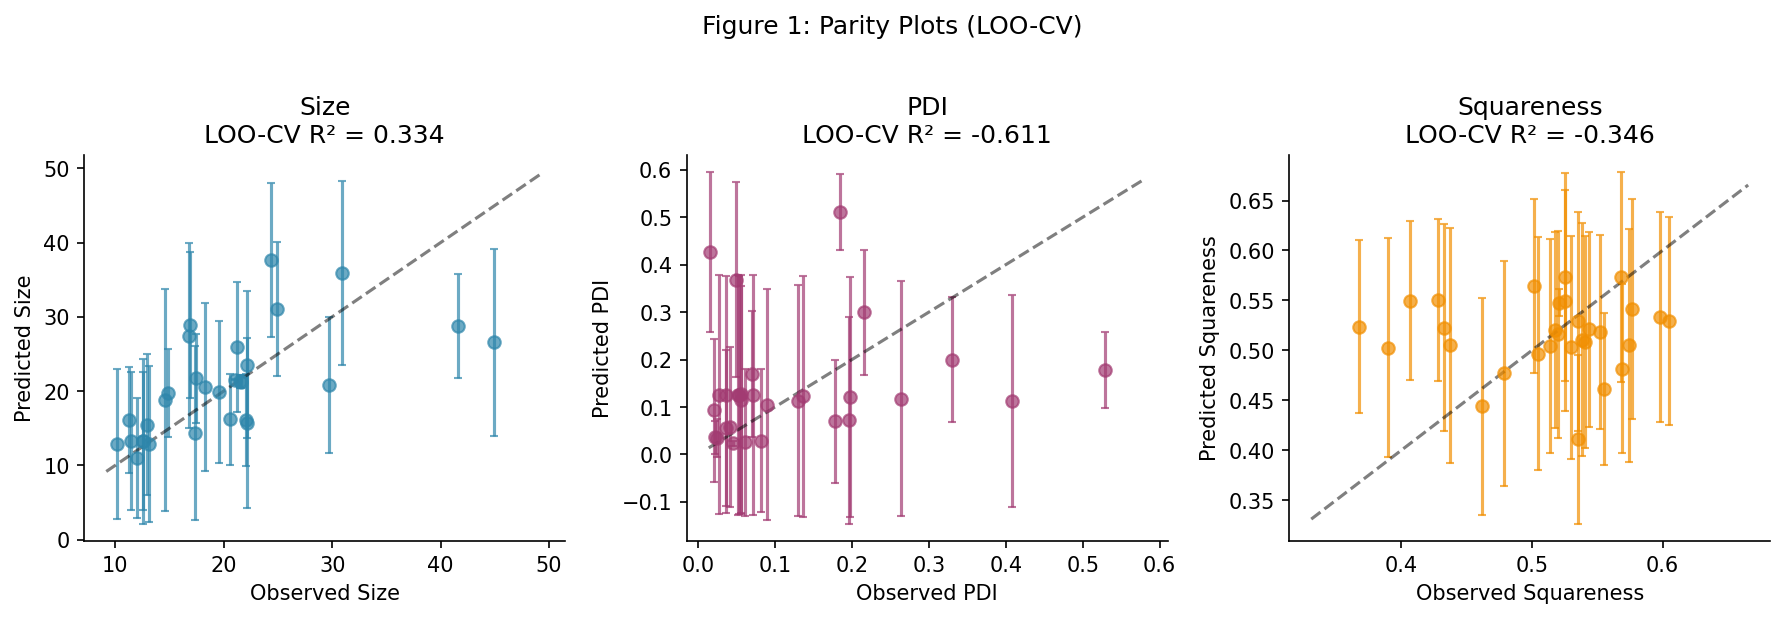

In [10]:
# =============================================================================
# CELL 10: FIGURE 1 - PARITY PLOTS
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, gp, col, color) in zip(axes, [
    ("Size", bo.gp_size, "Size", COLORS['primary']),
    ("PDI", bo.gp_pdi, "PDI", COLORS['secondary']),
    ("Squareness", bo.gp_sq, "Squareness", COLORS['tertiary'])
]):
    X, y = bo.X_props_scaled, bo.df_props[col].values
    
    # LOO-CV predictions
    y_pred, y_std = [], []
    for train_idx, test_idx in LeaveOneOut().split(X):
        gp_cv = make_gp_regressor(X.shape[1])
        gp_cv.fit(X[train_idx], y[train_idx])
        mu, std = gp_cv.predict(X[test_idx], return_std=True)
        y_pred.append(mu[0])
        y_std.append(std[0])
    
    y_pred, y_std = np.array(y_pred), np.array(y_std)
    r2 = r2_score(y, y_pred)
    
    ax.errorbar(y, y_pred, yerr=1.96*y_std, fmt='o', color=color, alpha=0.7, capsize=2, markersize=6)
    lims = [min(y.min(), y_pred.min())*0.9, max(y.max(), y_pred.max())*1.1]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel(f"Observed {col}")
    ax.set_ylabel(f"Predicted {col}")
    ax.set_title(f"{name}\nLOO-CV R² = {r2:.3f}")

plt.suptitle("Figure 1: Parity Plots (LOO-CV)", y=1.02)
plt.tight_layout()
plt.savefig("figure1_parity.png", dpi=300, bbox_inches='tight')
plt.show()

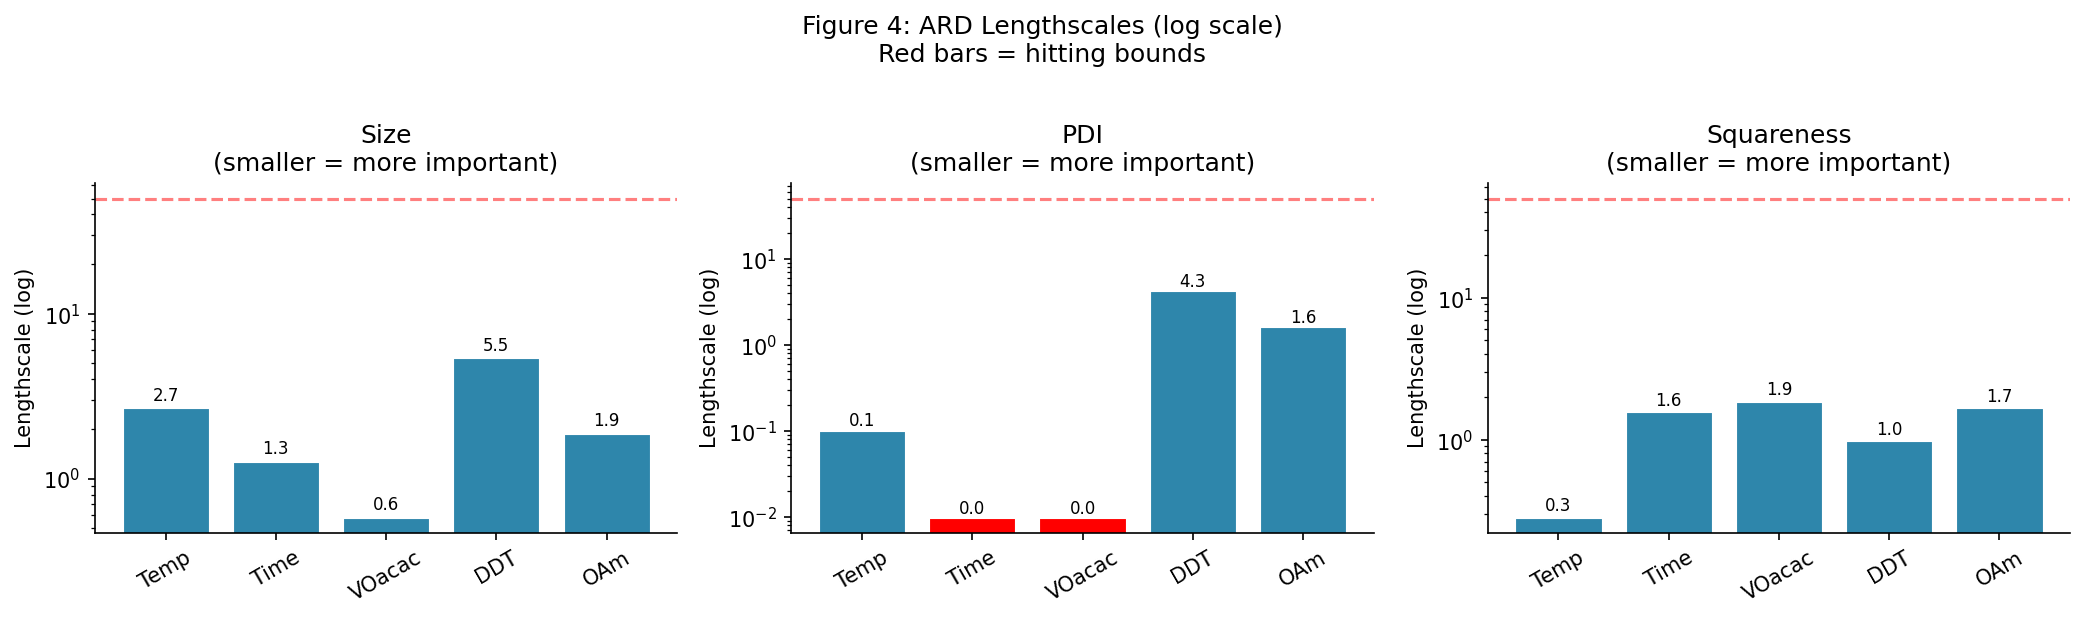

In [11]:
# =============================================================================
# CELL 11: FIGURE 4 - LENGTHSCALE ANALYSIS
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, gp) in zip(axes, [("Size", bo.gp_size), ("PDI", bo.gp_pdi), ("Squareness", bo.gp_sq)]):
    try:
        ls = np.array(gp.kernel_.k1.k2.length_scale)
        colors = ['red' if l > 50 or l < 0.05 else COLORS['primary'] for l in ls]
        
        bars = ax.bar(FACTOR_ORDER, ls, color=colors, edgecolor='white', linewidth=1.5)
        ax.set_yscale('log')
        ax.set_ylabel("Lengthscale (log)")
        ax.set_title(f"{name}\n(smaller = more important)")
        ax.tick_params(axis='x', rotation=30)
        ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
        
        for bar, val in zip(bars, ls):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.1, f'{val:.1f}', ha='center', fontsize=8)
    except:
        ax.text(0.5, 0.5, "Error", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Figure 4: ARD Lengthscales (log scale)\nRed bars = hitting bounds", y=1.02)
plt.tight_layout()
plt.savefig("figure4_lengthscales.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# =============================================================================
# CELL 12: CORRELATION ANALYSIS
# =============================================================================
print("CORRELATION ANALYSIS")
print("="*60)

df_success = df[df["HasProduct"] == 1]

print(f"\n{'Factor':<10} {'Size':>12} {'PDI':>12} {'Squareness':>12}")
print("-"*50)

for factor in FACTOR_ORDER:
    corrs = []
    for obj in ["Size", "PDI", "Squareness"]:
        r, p = spearmanr(df_success[factor], df_success[obj])
        sig = "**" if p < 0.01 else "*" if p < 0.05 else ""
        corrs.append(f"{r:+.3f}{sig}")
    print(f"{factor:<10} {corrs[0]:>12} {corrs[1]:>12} {corrs[2]:>12}")

print("-"*50)
print("* p<0.05, ** p<0.01")

CORRELATION ANALYSIS

Factor             Size          PDI   Squareness
--------------------------------------------------
Temp             +0.012       -0.220       +0.358
Time             +0.095       +0.156       -0.009
VOacac         +0.608**       -0.121       -0.240
DDT              +0.285       -0.122     -0.513**
OAm              +0.100       -0.056       -0.252
--------------------------------------------------
* p<0.05, ** p<0.01


DIAGNOSTIC: Why is GP failing on PDI?

1. IS PDI PREDICTABLE? (Model comparison)
--------------------------------------------------
Random Forest R²:      -1.328 ± 1.225
Gradient Boosting R²:  -2.947 ± 1.771

→ PDI may have high inherent noise or missing key variables.

2. NON-LINEAR RELATIONSHIPS?
--------------------------------------------------


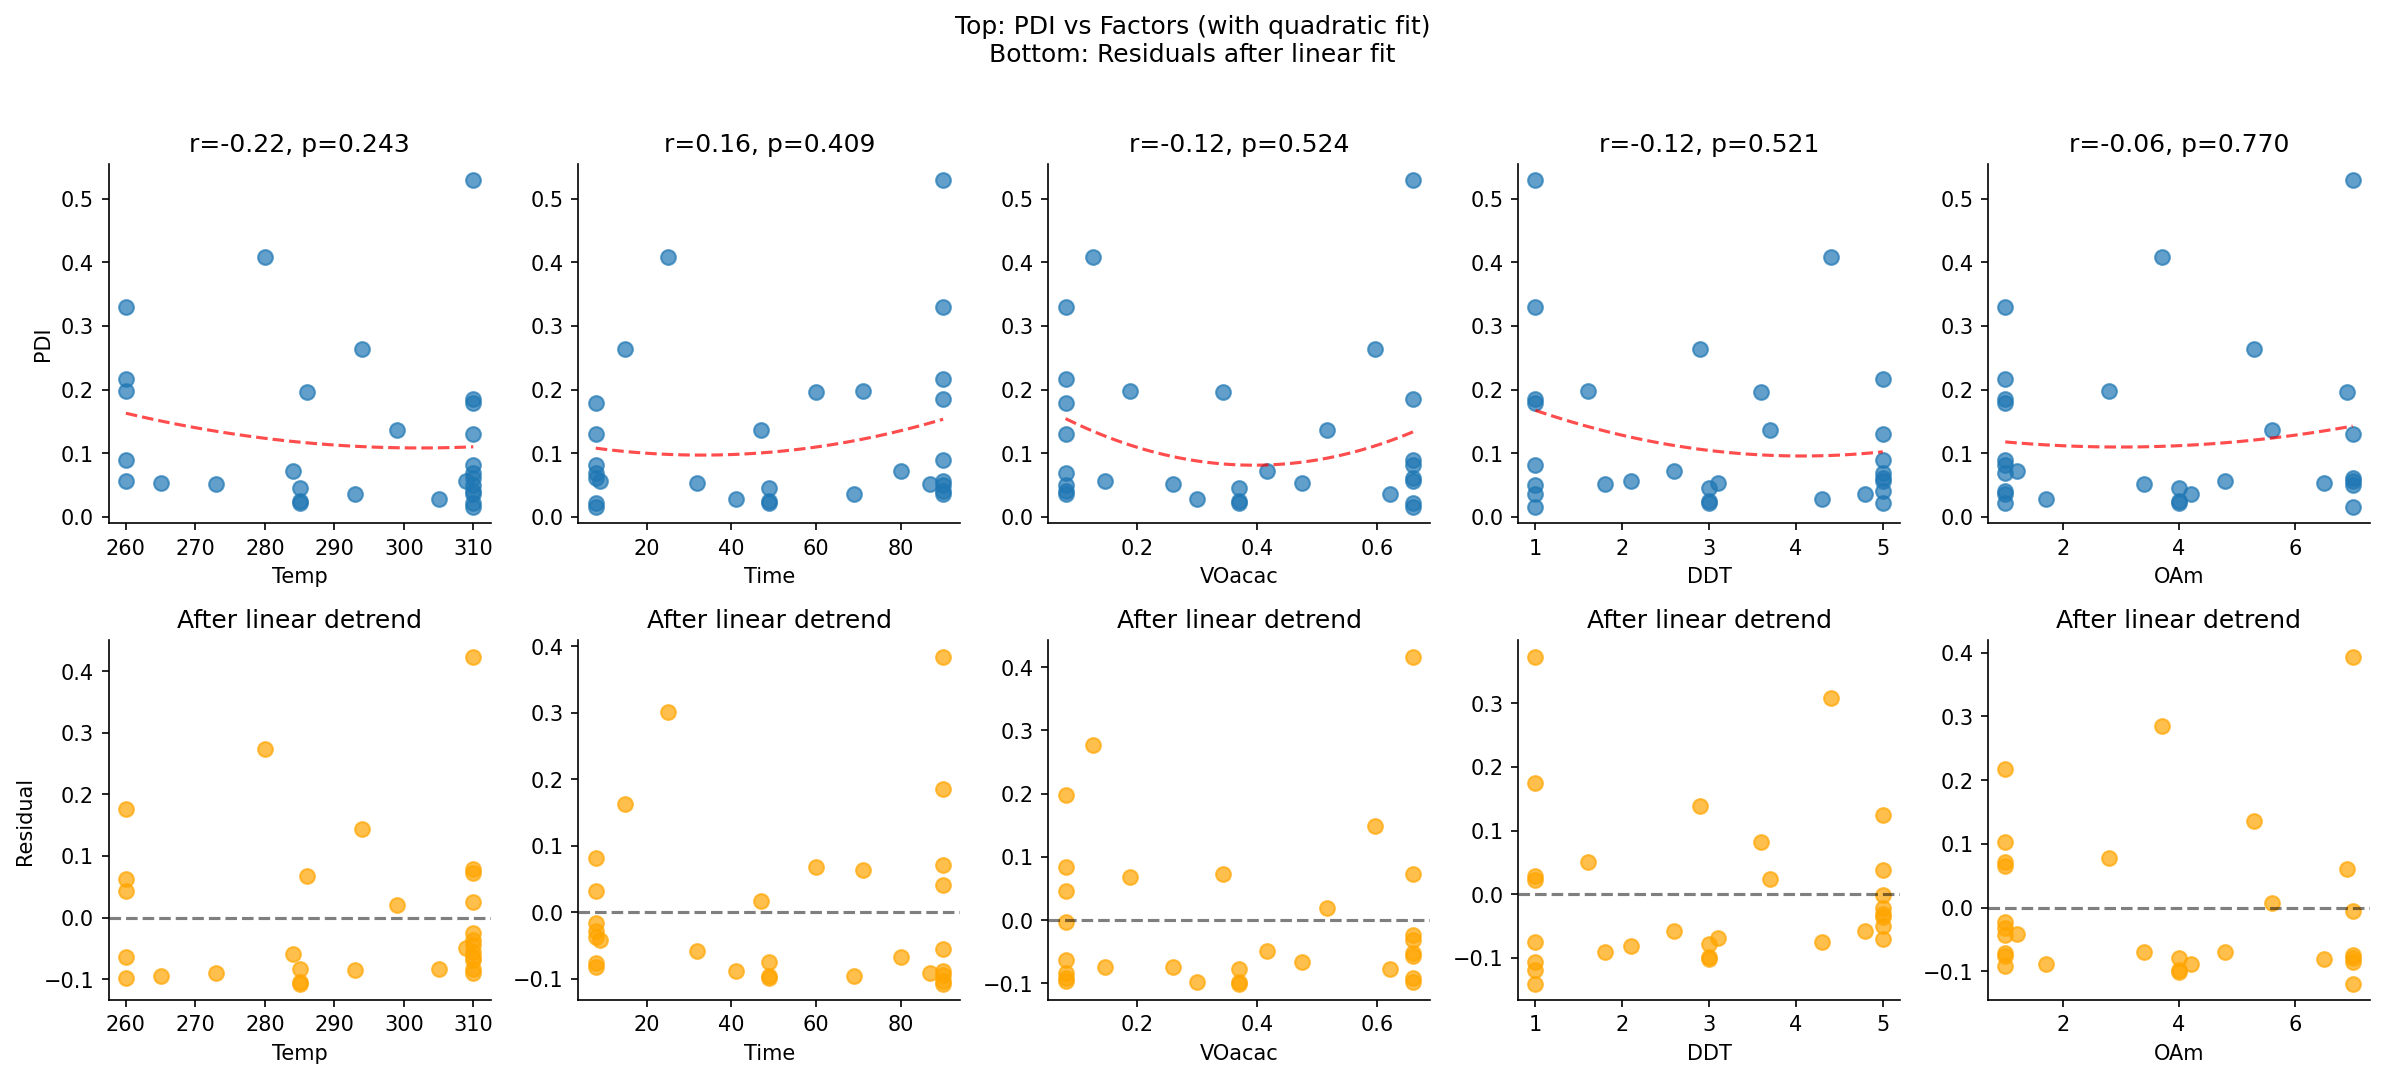


3. OUTLIERS OR REGIME CHANGES?
--------------------------------------------------
Potential outliers: 2 / 30
Outlier PDI values: [0.52883973 0.40845255]
Outlier conditions:


,Temp,Time,VOacac,DDT,OAm,PDI,Size,Squareness
27,310,90,0.660,1.0,7.0,0.528840,16.810,0.535
30,280,25,0.125,4.4,3.7,0.408453,12.589,0.538



4. DO INTERACTIONS MATTER?
--------------------------------------------------

Random Forest Feature Importances:
  VOacac    : 0.250
  DDT       : 0.194
  Temp      : 0.188
  Time      : 0.188
  OAm       : 0.179

With explicit interactions:
RF R² (main effects only):  -1.328
RF R² (with interactions):  -2.294

5. REGIME ANALYSIS
--------------------------------------------------
Low temp (≤296.5°C): n=15, PDI mean=0.138, std=0.119
High temp (>296.5°C): n=15, PDI mean=0.108, std=0.124

Low VOacac (≤0.37): n=17, PDI mean=0.122, std=0.112
High VOacac (>0.37): n=13, PDI mean=0.123, std=0.135

6. ALTERNATIVE GP APPROACHES
--------------------------------------------------
Testing different GP kernels:
  Matern 5/2 (ARD)         : R² = -2.129 ± 3.882
  Matern 3/2 (ARD)         : R² = -1.418 ± 2.377
  RBF (ARD)                : R² = -3.448 ± 6.250
  RationalQuadratic        : R² = -0.615 ± 0.657
  Matern 5/2 (Isotropic)   : R² = -0.589 ± 0.677

SUMMARY

Best RF R² achieved: -1.328

If RF R

In [13]:
# =============================================================================
# WHY IS THE GP FAILING ON PDI?
# =============================================================================
# Your data has plenty of diversity (PDI range 0.015-0.529, CV=100%)
# So the problem isn't lack of signal - it's something about the GP assumptions
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Load data (adjust path as needed)
# df = pd.read_csv("COMPLETE_CUVS_DATA_PDI.csv")
df_success = df[df["HasProduct"] == 1].copy()

FACTOR_ORDER = ["Temp", "Time", "VOacac", "DDT", "OAm"]
X = df_success[FACTOR_ORDER].values
y_pdi = df_success["PDI"].values

print("=" * 70)
print("DIAGNOSTIC: Why is GP failing on PDI?")
print("=" * 70)

# =============================================================================
# TEST 1: Is PDI predictable at all? (Random Forest as upper bound)
# =============================================================================
print("\n1. IS PDI PREDICTABLE? (Model comparison)")
print("-" * 50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Random Forest - can capture non-linear relationships
rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=2, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y_pdi, cv=5, scoring='r2')

# Gradient Boosting - can capture complex interactions
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42)
gb_scores = cross_val_score(gb, X_scaled, y_pdi, cv=5, scoring='r2')

print(f"Random Forest R²:      {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"Gradient Boosting R²:  {gb_scores.mean():.3f} ± {gb_scores.std():.3f}")

if rf_scores.mean() > 0.2:
    print("\n→ PDI IS predictable! The issue is GP-specific, not data-related.")
else:
    print("\n→ PDI may have high inherent noise or missing key variables.")

# =============================================================================
# TEST 2: Non-linear relationships? (Scatter plots with LOWESS)
# =============================================================================
print("\n2. NON-LINEAR RELATIONSHIPS?")
print("-" * 50)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for j, factor in enumerate(FACTOR_ORDER):
    x = df_success[factor].values
    
    # Top row: PDI vs factor
    ax = axes[0, j]
    ax.scatter(x, y_pdi, alpha=0.7, s=50)
    ax.set_xlabel(factor)
    ax.set_ylabel("PDI" if j == 0 else "")
    r, p = spearmanr(x, y_pdi)
    ax.set_title(f"r={r:.2f}, p={p:.3f}")
    
    # Add quadratic fit to check for U-shape
    try:
        z = np.polyfit(x, y_pdi, 2)
        p_fit = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_line, p_fit(x_line), 'r--', alpha=0.7, label='Quadratic fit')
    except:
        pass
    
    # Bottom row: Residuals after linear fit (to see non-linearity)
    ax = axes[1, j]
    z_lin = np.polyfit(x, y_pdi, 1)
    residuals = y_pdi - np.polyval(z_lin, x)
    ax.scatter(x, residuals, alpha=0.7, s=50, c='orange')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel(factor)
    ax.set_ylabel("Residual" if j == 0 else "")
    ax.set_title("After linear detrend")

axes[0, 0].set_ylabel("PDI")
axes[1, 0].set_ylabel("Residual")

plt.suptitle("Top: PDI vs Factors (with quadratic fit)\nBottom: Residuals after linear fit", y=1.02)
plt.tight_layout()
plt.savefig("pdi_nonlinearity_check.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# TEST 3: Outliers or regime changes?
# =============================================================================
print("\n3. OUTLIERS OR REGIME CHANGES?")
print("-" * 50)

# Check for outliers in PDI
q1, q3 = np.percentile(y_pdi, [25, 75])
iqr = q3 - q1
outlier_mask = (y_pdi < q1 - 1.5*iqr) | (y_pdi > q3 + 1.5*iqr)
print(f"Potential outliers: {outlier_mask.sum()} / {len(y_pdi)}")

if outlier_mask.sum() > 0:
    print("Outlier PDI values:", y_pdi[outlier_mask])
    print("Outlier conditions:")
    display(df_success[outlier_mask][FACTOR_ORDER + ["PDI", "Size", "Squareness"]])

# =============================================================================
# TEST 4: Interactions - do factor COMBINATIONS matter?
# =============================================================================
print("\n4. DO INTERACTIONS MATTER?")
print("-" * 50)

# Fit RF and get feature importances (captures interactions implicitly)
rf_full = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_full.fit(X_scaled, y_pdi)

importances = rf_full.feature_importances_
print("\nRandom Forest Feature Importances:")
for f, imp in sorted(zip(FACTOR_ORDER, importances), key=lambda x: -x[1]):
    print(f"  {f:<10}: {imp:.3f}")

# Create explicit interactions and test
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_interact = poly.fit_transform(X_scaled)

rf_interact = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf_interact_scores = cross_val_score(rf_interact, X_interact, y_pdi, cv=5, scoring='r2')

print(f"\nWith explicit interactions:")
print(f"RF R² (main effects only):  {rf_scores.mean():.3f}")
print(f"RF R² (with interactions):  {rf_interact_scores.mean():.3f}")

# =============================================================================
# TEST 5: Is it a specific regime causing problems?
# =============================================================================
print("\n5. REGIME ANALYSIS")
print("-" * 50)

# Split by temperature (nucleation vs growth dominated)
temp_median = df_success["Temp"].median()
low_temp = df_success["Temp"] <= temp_median
high_temp = df_success["Temp"] > temp_median

print(f"Low temp (≤{temp_median}°C): n={low_temp.sum()}, PDI mean={y_pdi[low_temp].mean():.3f}, std={y_pdi[low_temp].std():.3f}")
print(f"High temp (>{temp_median}°C): n={high_temp.sum()}, PDI mean={y_pdi[high_temp].mean():.3f}, std={y_pdi[high_temp].std():.3f}")

# Split by VOacac (precursor concentration)
vo_median = df_success["VOacac"].median()
low_vo = df_success["VOacac"] <= vo_median
high_vo = df_success["VOacac"] > vo_median

print(f"\nLow VOacac (≤{vo_median}): n={low_vo.sum()}, PDI mean={y_pdi[low_vo].mean():.3f}, std={y_pdi[low_vo].std():.3f}")
print(f"High VOacac (>{vo_median}): n={high_vo.sum()}, PDI mean={y_pdi[high_vo].mean():.3f}, std={y_pdi[high_vo].std():.3f}")

# =============================================================================
# TEST 6: What if we use a different GP kernel?
# =============================================================================
print("\n6. ALTERNATIVE GP APPROACHES")
print("-" * 50)

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, RationalQuadratic, ExpSineSquared, ConstantKernel as C, WhiteKernel

kernels_to_test = {
    "Matern 5/2 (ARD)": C(1.0) * Matern(length_scale=[1.0]*5, nu=2.5) + WhiteKernel(0.1),
    "Matern 3/2 (ARD)": C(1.0) * Matern(length_scale=[1.0]*5, nu=1.5) + WhiteKernel(0.1),
    "RBF (ARD)": C(1.0) * RBF(length_scale=[1.0]*5) + WhiteKernel(0.1),
    "RationalQuadratic": C(1.0) * RationalQuadratic(length_scale=1.0) + WhiteKernel(0.1),
    "Matern 5/2 (Isotropic)": C(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(0.1),
}

print("Testing different GP kernels:")
for name, kernel in kernels_to_test.items():
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=42)
    try:
        scores = cross_val_score(gp, X_scaled, y_pdi, cv=5, scoring='r2')
        print(f"  {name:<25}: R² = {scores.mean():.3f} ± {scores.std():.3f}")
    except Exception as e:
        print(f"  {name:<25}: Failed - {e}")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

best_rf = max(rf_scores.mean(), rf_interact_scores.mean())
print(f"""
Best RF R² achieved: {best_rf:.3f}

If RF R² > 0.2 but GP fails:
  → The function has non-stationary or non-smooth behavior
  → Solution: Use Random Forest or Gradient Boosting for PDI instead of GP

If RF R² < 0.1:
  → PDI genuinely has high noise or depends on unmeasured variables
  → Solution: Report uncertainty honestly, focus on Size/Squareness

Check the plots above for:
  - U-shaped relationships (quadratic fits)
  - Outliers driving the model
  - Different behavior in different regimes
""")